# Intégration LLM : Explications des Fraudes Détectées

**Provider :** Groq / Gemini

**Objectif :** Générer des explications en langage naturel pour les transactions
détectées comme frauduleuses par l'AutoEncoder (NB05).

**Pipeline :**
1. Charger les scores de reconstruction de l'AutoEncoder
2. Identifier les transactions frauduleuses (score > seuil)
3. Calculer l'erreur par feature pour chaque transaction
4. Envoyer un prompt structuré au LLM
5. Parser et sauvegarder les explications JSON
6. Analyse et visualisation des explications

**Prérequis :**
```bash
pip install groq
```

In [1]:
from pathlib import Path
import sys, json, time, warnings
import yaml
import os
from dotenv import load_dotenv
load_dotenv()  # charge .env avant os.getenv (resout GROQ_API_KEY, etc.)
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Chemins ───────────────────────────────────────────────────────────────────
project_root = Path('.').resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

CONFIG_DIR        = project_root / 'config'
CONFIG_PATH       = CONFIG_DIR / 'config.yaml'
LLM_CONFIG_PATH   = CONFIG_DIR / 'llm_config.yaml'


def load_yaml_config(path):
    with open(path, encoding='utf-8') as f:
        return yaml.safe_load(f) or {}


def resolve_env_vars(value):
    """Résout les placeholders ${VAR_NAME} depuis les variables d'environnement."""
    if isinstance(value, str) and value.startswith('${') and value.endswith('}'):
        var_name = value[2:-1]
        return os.getenv(var_name, value)
    return value


project_config = load_yaml_config(CONFIG_PATH)
llm_config     = load_yaml_config(LLM_CONFIG_PATH)

data_config   = project_config.get('data', {})
output_config = project_config.get('output', {})

# ── Variables LLM (lues depuis llm_config.yaml) ───────────────────────────
generation_cfg = llm_config.get('generation', {})
pipeline_cfg   = llm_config.get('pipeline', {})
llm_output_cfg = llm_config.get('output', {})

LLM_PROVIDER    = llm_config.get('active_provider', llm_config.get('provider', 'groq'))
LLM_API_KEY     = resolve_env_vars(llm_config.get('api_keys', {}).get(LLM_PROVIDER, ''))
LLM_MODEL       = llm_config.get('models', {}).get(LLM_PROVIDER, 'llama3-8b-8192')
LLM_TIMEOUT     = int(generation_cfg.get('timeout', 30))
LLM_TEMPERATURE = float(generation_cfg.get('temperature', 0.1))
LLM_MAX_TOKENS  = int(generation_cfg.get('max_tokens', 400))
LLM_TOP_K_FEATURES = int(pipeline_cfg.get('top_k_features', 3))
LLM_MAX_EXPLAIN    = int(pipeline_cfg.get('max_explain', 20))
LLM_BATCH_VERBOSE  = bool(pipeline_cfg.get('batch_verbose', True))

PROCESSED_DIR = project_root / data_config.get('processed_path', 'data/processed/')
MODELS_DIR    = project_root / output_config.get('models_dir', 'outputs/models/')
REPORTS_DIR   = project_root / output_config.get('reports_dir', 'outputs/reports/')
FIGURES_DIR   = project_root / output_config.get('figures_dir', 'outputs/figures/')

EXPLANATIONS_PATH  = Path(llm_output_cfg.get('explanations_file',
                          str(REPORTS_DIR / 'explanations.json')))
LLM_SUMMARY_PATH   = Path(llm_output_cfg.get('summary_file',
                          str(REPORTS_DIR / 'llm_summary.json')))

print(f'Project root   : {project_root}')
print(f'LLM config     : {LLM_CONFIG_PATH}')
print(f'LLM Provider   : {LLM_PROVIDER}')
print(f'LLM Model      : {LLM_MODEL}')
print(f'API Key found  : {bool(LLM_API_KEY and not LLM_API_KEY.startswith("${"))}')

Project root   : C:\Users\lenovo\Desktop\anomaly_detection_project
LLM config     : C:\Users\lenovo\Desktop\anomaly_detection_project\config\llm_config.yaml
LLM Provider   : groq
LLM Model      : llama-3.1-8b-instant
API Key found  : True


## 1 — Constantes et Références

In [2]:
RANDOM_STATE = 42

# ── Références NB04 (à charger depuis le rapport) ────────────────────────────
with open(REPORTS_DIR / 'autoencoder_report.json', encoding='utf-8') as f:
    ae_report = json.load(f)

threshold_report = ae_report.get('threshold', {})
AE_THRESHOLD = ae_report.get('threshold_optimal', threshold_report.get('optimal'))
if AE_THRESHOLD is None:
    raise KeyError("Seuil AE introuvable dans autoencoder_report.json (attendu: 'threshold.optimal' ou 'threshold_optimal')")
AE_RECALL_TEST  = ae_report['test_metrics']['recall']
AE_F1_TEST      = ae_report['test_metrics']['f1']

# ── Références NB03 (meilleur modèle ML) ────────────────────────────────────
with open(REPORTS_DIR / 'baseline_report.json', encoding='utf-8') as f:
    baseline_report = json.load(f)

rf_report = next((model for model in baseline_report.get('models', []) if model.get('name') == 'RF_smote'), None)
if rf_report is None:
    raise KeyError("Modèle RF_smote introuvable dans baseline_report.json")

RF_RECALL = rf_report['test_metrics']['recall']
RF_F1     = rf_report['test_metrics']['f1']

print('Références chargées depuis les rapports :')
print(f'  AE seuil optimal : {AE_THRESHOLD:.6f}')
print(f'  AE Recall test   : {AE_RECALL_TEST:.4f}')
print(f'  AE F1 test       : {AE_F1_TEST:.4f}')
print(f'  RF_smote Recall  : {RF_RECALL:.4f}')
print(f'  RF_smote F1      : {RF_F1:.4f}')

Références chargées depuis les rapports :
  AE seuil optimal : 1.753022
  AE Recall test   : 0.3590
  AE F1 test       : 0.4516
  RF_smote Recall  : 0.7949
  RF_smote F1      : 0.8052


## 2 — Chargement des modules src/

In [3]:
import importlib

modules_to_check = [
    'src.models.autoencoder',
    'src.llm_integration.llm_helper',
    'src.utils.evaluator',
]

all_ok = True
for mod in modules_to_check:
    try:
        importlib.import_module(mod)
        print(f'  ✅ {mod}')
    except Exception as e:
        print(f'  ❌ {mod} → {e}')
        all_ok = False

assert all_ok, 'Certains modules src/ sont manquants ou cassés.'

from src.models.autoencoder              import FraudAutoEncoder
from src.llm_integration.llm_helper      import LLMHelper
from src.utils.evaluator                 import compute_fraud_metrics

print('\n✅ Modules src chargés.')

  ✅ src.models.autoencoder
  ✅ src.llm_integration.llm_helper
  ✅ src.utils.evaluator

✅ Modules src chargés.


## 3 — Chargement des données et artefacts

In [4]:
# ── Features ──────────────────────────────────────────────────────────────────
with open(MODELS_DIR / 'features.json', encoding='utf-8') as f:
    meta = json.load(f)

FEATURE_COLS = meta.get('feature_cols') or meta.get('all_features')
if FEATURE_COLS is None:
    raise KeyError("Impossible de trouver la liste des features dans features.json (attendu: 'feature_cols' ou 'all_features')")
TARGET       = meta.get('target', 'isFraud')

print(f'Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}')
print(f'Target : {TARGET}')

Features (14) : ['step', 'hour', 'day', 'week', 'high_risk_hour', 'is_transfer_or_cashout', 'balance_diff_orig', 'dest_zero_balance', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'log_amount']
Target : isFraud


In [5]:
# ── Chargement X_test et y_test ───────────────────────────────────────────────
def load_split(prefix):
    csv_X = PROCESSED_DIR / f'X_{prefix}.csv'
    csv_y = PROCESSED_DIR / f'y_{prefix}.csv'
    if csv_X.exists():
        X = pd.read_csv(csv_X)
        y = pd.read_csv(csv_y).iloc[:, 0]
    else:
        X = pd.DataFrame(
            np.load(PROCESSED_DIR / f'X_{prefix}.npy', allow_pickle=True).astype(float),
            columns=FEATURE_COLS
        )
        y = pd.Series(
            np.load(PROCESSED_DIR / f'y_{prefix}.npy', allow_pickle=True).astype(int),
            name=TARGET
        )
    X = X[FEATURE_COLS].astype(float)
    y = y.astype(int)
    return X, y

X_test, y_test = load_split('test')
X_val,  y_val  = load_split('val')

print(f'X_test : {X_test.shape}  fraudes={int(y_test.sum())}')
print(f'X_val  : {X_val.shape}   fraudes={int(y_val.sum())}')

X_test : (30001, 14)  fraudes=39
X_val  : (30000, 14)   fraudes=38


In [6]:
# ── Chargement AutoEncoder ────────────────────────────────────────────────────
ae = FraudAutoEncoder.load(MODELS_DIR / 'autoencoder')
print(f'AutoEncoder chargé')
print(f'  Seuil optimal : {ae.threshold:.6f}')
print(f'  Architecture  : {ae}')

# ── Chargement scores de reconstruction (pré-calculés dans NB04) ─────────────
#ae_scores_test = np.load(MODELS_DIR / 'ae_scores_test.npy')
def safe_load(path):
    if not path.exists():
        raise FileNotFoundError(f"Fichier manquant : {path}")
    return np.load(path)

ae_scores_test = safe_load(MODELS_DIR / 'ae_scores_test.npy')
ae_scores_val  = np.load(MODELS_DIR / 'ae_scores_val.npy')

print(f'\nScores chargés :')
print(f'  ae_scores_test : {ae_scores_test.shape}  min={ae_scores_test.min():.4f}  max={ae_scores_test.max():.4f}')
print(f'  ae_scores_val  : {ae_scores_val.shape}   min={ae_scores_val.min():.4f}  max={ae_scores_val.max():.4f}')

AutoEncoder chargé
  Seuil optimal : 1.753022
  Architecture  : <src.models.autoencoder.FraudAutoEncoder object at 0x00000170905C82F0>

Scores chargés :
  ae_scores_test : (30001,)  min=0.0146  max=313.6496
  ae_scores_val  : (30000,)   min=0.0151  max=314.1599


## 4 — Identification des transactions frauduleuses détectées

In [7]:
threshold = AE_THRESHOLD

# Prédictions AE sur test
y_pred_ae = (ae_scores_test >= threshold).astype(int)

# Transactions flaggées comme fraudes par l'AE
flagged_mask   = y_pred_ae == 1
flagged_idx    = np.where(flagged_mask)[0]

# Vrais positifs (TP) et faux positifs (FP)
y_test_arr     = np.asarray(y_test)
tp_mask        = flagged_mask & (y_test_arr == 1)
fp_mask        = flagged_mask & (y_test_arr == 0)
fn_mask        = (~flagged_mask) & (y_test_arr == 1)

n_flagged = flagged_mask.sum()
n_tp      = tp_mask.sum()
n_fp      = fp_mask.sum()
n_fn      = fn_mask.sum()

print(f'Seuil AE       : {threshold:.6f}')
print(f'Transactions flaggées : {n_flagged}')
print(f'  TP (vraies fraudes détectées) : {n_tp}')
print(f'  FP (fausses alertes)          : {n_fp}')
print(f'  FN (fraudes manquées)         : {n_fn}')
print(f'  Recall : {n_tp / int(y_test.sum()):.4f}')

Seuil AE       : 1.753022
Transactions flaggées : 23
  TP (vraies fraudes détectées) : 14
  FP (fausses alertes)          : 9
  FN (fraudes manquées)         : 25
  Recall : 0.3590


## 5 — Calcul des erreurs de reconstruction par feature

In [8]:
# Reconstruction de toutes les transactions du test set
print('Calcul des erreurs de reconstruction par feature...')
t0 = time.time()

import torch

X_test_arr  = X_test.values.astype(np.float32)
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_arr).to(ae.device)
    X_test_rec = ae.model(X_test_tensor).cpu().numpy()

# Erreur absolue par feature : shape (N, 14)
feature_errors_test = np.abs(X_test_arr - X_test_rec)

print(f'✅ Erreurs calculées en {time.time()-t0:.1f}s')
print(f'   Shape feature_errors_test : {feature_errors_test.shape}')

# Vérification : top-3 features pour la transaction avec le score le plus élevé
worst_idx   = np.argmax(ae_scores_test)
worst_errs  = feature_errors_test[worst_idx]
top3_idx    = np.argsort(worst_errs)[::-1][:3]

print(f'\nTransaction la plus anormale (idx={worst_idx}, score={ae_scores_test[worst_idx]:.4f}) :')
for i, fi in enumerate(top3_idx, 1):
    print(f'  {i}. {FEATURE_COLS[fi]:30s} erreur={worst_errs[fi]:.4f}')

Calcul des erreurs de reconstruction par feature...


✅ Erreurs calculées en 0.2s
   Shape feature_errors_test : (30001, 14)

Transaction la plus anormale (idx=29340, score=313.6496) :
  1. balance_diff_orig              erreur=65.7344
  2. log_amount                     erreur=5.8698
  3. type_PAYMENT                   erreur=1.6641


## 6 — Initialisation du provider LLM

In [9]:
# ── Initialisation LLMHelper (Groq / Gemini / HuggingFace) ───────────────────
try:
    FEATURE_COLS
except NameError:
    with open(MODELS_DIR / 'features.json', encoding='utf-8') as f:
        meta = json.load(f)
    FEATURE_COLS = meta.get('feature_cols') or meta.get('all_features')
    if FEATURE_COLS is None:
        raise KeyError("Impossible de trouver la liste des features dans features.json (attendu: 'feature_cols' ou 'all_features')")
    print(f'Features initialisées ({len(FEATURE_COLS)}) : {FEATURE_COLS}')

from importlib.util import module_from_spec, spec_from_file_location

llm_helper_path = project_root / 'src' / 'llm_integration' / 'llm_helper.py'
spec = spec_from_file_location('llm_helper_module', llm_helper_path)
llm_helper_module = module_from_spec(spec)
assert spec and spec.loader
spec.loader.exec_module(llm_helper_module)
LLMHelper = llm_helper_module.LLMHelper
PROVIDERS = llm_helper_module.PROVIDERS

helper = LLMHelper(
    provider      = LLM_PROVIDER,
    api_key       = LLM_API_KEY,
    timeout       = LLM_TIMEOUT,
    temperature   = LLM_TEMPERATURE,
    max_tokens    = LLM_MAX_TOKENS,
    feature_names = FEATURE_COLS,
    config_path   = str(LLM_CONFIG_PATH),
)

llm_ok = helper.is_available()
print(f'Provider       : {LLM_PROVIDER}')
print(f'Modele         : {LLM_MODEL}')
print(f'API disponible : {llm_ok}')

if not llm_ok:
    print()
    print('  -> Cle API manquante ou invalide.')
    print(f'  -> Mode fallback rule-based active.')
    print()
    print('  Pour activer le LLM :')
    print(f'  1. Ouvrir config/llm_config.yaml')
    print(f'  2. Renseigner api_keys.{LLM_PROVIDER} avec votre cle gratuite')
    print(f'  3. Obtenir une cle sur :')
    print(f'     {PROVIDERS[LLM_PROVIDER]["signup"]}')
else:
    print(f'  ✅ Pret a generer des explications LLM via {LLM_PROVIDER.upper()}')

Provider       : groq
Modele         : llama-3.1-8b-instant
API disponible : True
  ✅ Pret a generer des explications LLM via GROQ


## 7 — Test sur une seule transaction

In [10]:
# ── Prendre la transaction TP avec le score le plus élevé ────────────────────
from pathlib import Path

try:
    project_root
except NameError:
    project_root = Path('.').resolve().parent

try:
    FEATURE_COLS
except NameError:
    with open(project_root / 'outputs' / 'models' / 'features.json', encoding='utf-8') as f:
        meta = json.load(f)
    FEATURE_COLS = meta.get('feature_cols') or meta.get('all_features')

try:
    PROCESSED_DIR
except NameError:
    PROCESSED_DIR = project_root / 'data' / 'processed'

try:
    MODELS_DIR
except NameError:
    MODELS_DIR = project_root / 'outputs' / 'models'

try:
    threshold
except NameError:
    try:
        threshold = AE_THRESHOLD
    except NameError:
        with open(project_root / 'outputs' / 'reports' / 'autoencoder_report.json', encoding='utf-8') as f:
            ae_report = json.load(f)
        threshold_report = ae_report.get('threshold', {})
        threshold = ae_report.get('threshold_optimal', threshold_report.get('optimal'))

try:
    X_test_arr
except NameError:
    if (PROCESSED_DIR / 'X_test.csv').exists():
        X_test_arr = pd.read_csv(PROCESSED_DIR / 'X_test.csv')[FEATURE_COLS].astype(float).values.astype(np.float32)
    else:
        X_test_arr = np.load(PROCESSED_DIR / 'X_test.npy', allow_pickle=True).astype(np.float32)

try:
    y_test
except NameError:
    if (PROCESSED_DIR / 'y_test.csv').exists():
        y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').iloc[:, 0].astype(int)
    else:
        y_test = pd.Series(np.load(PROCESSED_DIR / 'y_test.npy', allow_pickle=True).astype(int), name='isFraud')

try:
    ae_scores_test
except NameError:
    ae_scores_test = np.load(MODELS_DIR / 'ae_scores_test.npy')

try:
    feature_errors_test
except NameError:
    try:
        ae
    except NameError:
        from src.models.autoencoder import FraudAutoEncoder
        ae = FraudAutoEncoder.load(MODELS_DIR / 'autoencoder')
    import torch
    X_test_tensor = torch.from_numpy(X_test_arr.astype(np.float32)).to(next(ae.model.parameters()).device)
    with torch.no_grad():
        X_test_rec = ae.model(X_test_tensor).cpu().numpy()
    feature_errors_test = np.abs(X_test_arr - X_test_rec)

try:
    tp_mask
except NameError:
    y_test_arr = np.asarray(y_test)
    tp_mask = (ae_scores_test >= threshold) & (y_test_arr == 1)

if not np.any(tp_mask):
    y_test_arr = np.asarray(y_test)
    fraud_idx = np.where(y_test_arr == 1)[0]
    if len(fraud_idx) == 0:
        raise ValueError('Aucune transaction frauduleuse disponible pour l\'explication.')
    best_tp_idx = fraud_idx[np.argmax(ae_scores_test[fraud_idx])]
    print('Aucun TP détecté au seuil courant, utilisation de la fraude la plus anormale.')
else:
    tp_indices = np.where(tp_mask)[0]
    best_tp_idx = tp_indices[np.argmax(ae_scores_test[tp_indices])]

transaction_dict = dict(zip(FEATURE_COLS, X_test_arr[best_tp_idx].tolist()))
feat_errors      = feature_errors_test[best_tp_idx]
score            = float(ae_scores_test[best_tp_idx])

print(f'Transaction test (TP, score={score:.4f}, idx={best_tp_idx}) :')
for feat, val in transaction_dict.items():
    print(f'  {feat:30s} = {val:.4f}')

print(f'\nTop-3 features les plus anormales :')
top3 = np.argsort(feat_errors)[::-1][:3]
for i, fi in enumerate(top3, 1):
    print(f'  {i}. {FEATURE_COLS[fi]:30s} erreur={feat_errors[fi]:.4f}')

Transaction test (TP, score=313.6496, idx=29340) :
  step                           = 3.4143
  hour                           = -1.2305
  day                            = 3.4564
  week                           = 3.4727
  high_risk_hour                 = 0.0000
  is_transfer_or_cashout         = 1.0000
  balance_diff_orig              = 66.0686
  dest_zero_balance              = 1.0000
  type_CASH_IN                   = 0.0000
  type_CASH_OUT                  = 0.0000
  type_DEBIT                     = 0.0000
  type_PAYMENT                   = 0.0000
  type_TRANSFER                  = 1.0000
  log_amount                     = 2.9061

Top-3 features les plus anormales :
  1. balance_diff_orig              erreur=65.7344
  2. log_amount                     erreur=5.8698
  3. type_PAYMENT                   erreur=1.6641


In [11]:
# ── Génération de l'explication ───────────────────────────────────────────────
print('Génération de l\'explication...\n')
t0 = time.time()

explanation = helper.explain_fraud(
    transaction     = transaction_dict,
    feature_errors  = feat_errors,
    ae_score        = score,
    threshold       = threshold,
    top_k           = LLM_TOP_K_FEATURES,
)

print(f'Durée : {time.time()-t0:.1f}s  |  Status : {explanation["status"]}')
print(f'Modèle utilisé : {explanation["model"]}')
print()
print(json.dumps(explanation, ensure_ascii=False, indent=2))

Génération de l'explication...



Durée : 0.6s  |  Status : ok
Modèle utilisé : llama-3.1-8b-instant

{
  "risk_level": "ELEVÉ",
  "risk_score": 0.178,
  "confidence_score": 0.78,
  "resume": "La transaction présente des anomalies concernant le solde du compte emetteur, le montant de la transaction et le type de transaction.",
  "raisons": [
    "La différence de solde du compte emetteur est anormalement élevée (erreur=65.7344)",
    "Le montant de la transaction est anormalement élevé (log-transforme) (erreur=5.8698)",
    "Le type PAYMENT présente une reconstruction anormale (erreur=1.6641)"
  ],
  "actions_recommandees": [
    "Vérifier le solde du compte emetteur et les transactions récentes",
    "Analyser les transactions similaires pour identifier des modèles anormaux"
  ],
  "ae_score": 313.649628,
  "threshold": 1.753022,
  "top_features": [
    {
      "feature": "balance_diff_orig",
      "error": 65.734421,
      "value": 66.06855
    },
    {
      "feature": "log_amount",
      "error": 5.869781,
      "v

## 8 — Génération batch sur toutes les fraudes détectées

In [12]:
# Préparer la liste des transactions flaggées
from pathlib import Path

try:
    project_root
except NameError:
    project_root = Path('.').resolve().parent

try:
    FEATURE_COLS
except NameError:
    with open(project_root / 'outputs' / 'models' / 'features.json', encoding='utf-8') as f:
        meta = json.load(f)
    FEATURE_COLS = meta.get('feature_cols') or meta.get('all_features')

try:
    PROCESSED_DIR
except NameError:
    PROCESSED_DIR = project_root / 'data' / 'processed'

try:
    MODELS_DIR
except NameError:
    MODELS_DIR = project_root / 'outputs' / 'models'

try:
    threshold
except NameError:
    try:
        threshold = AE_THRESHOLD
    except NameError:
        with open(project_root / 'outputs' / 'reports' / 'autoencoder_report.json', encoding='utf-8') as f:
            ae_report = json.load(f)
        threshold_report = ae_report.get('threshold', {})
        threshold = ae_report.get('threshold_optimal', threshold_report.get('optimal'))

try:
    X_test_arr
except NameError:
    if (PROCESSED_DIR / 'X_test.csv').exists():
        X_test_arr = pd.read_csv(PROCESSED_DIR / 'X_test.csv')[FEATURE_COLS].astype(float).values.astype(np.float32)
    else:
        X_test_arr = np.load(PROCESSED_DIR / 'X_test.npy', allow_pickle=True).astype(np.float32)

try:
    y_test
except NameError:
    if (PROCESSED_DIR / 'y_test.csv').exists():
        y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').iloc[:, 0].astype(int)
    else:
        y_test = pd.Series(np.load(PROCESSED_DIR / 'y_test.npy', allow_pickle=True).astype(int), name='isFraud')

try:
    ae_scores_test
except NameError:
    ae_scores_test = np.load(MODELS_DIR / 'ae_scores_test.npy')

try:
    flagged_idx
except NameError:
    y_test_arr = np.asarray(y_test)
    flagged_idx = np.where(ae_scores_test >= threshold)[0]
    tp_mask = (ae_scores_test >= threshold) & (y_test_arr == 1)
    fp_mask = (ae_scores_test >= threshold) & (y_test_arr == 0)

flagged_transactions = [
    dict(zip(FEATURE_COLS, X_test_arr[i].tolist()))
    for i in flagged_idx
]
flagged_errors = feature_errors_test[flagged_idx]
flagged_scores = ae_scores_test[flagged_idx]

print(f'Transactions à expliquer : {len(flagged_transactions)}')
print(f'  TP : {tp_mask[flagged_idx].sum()}')
print(f'  FP : {fp_mask[flagged_idx].sum()}')
print()

# Génération batch
print('Génération des explications...')
explanations = helper.explain_batch(
    transactions         = flagged_transactions,
    feature_errors_batch = flagged_errors,
    ae_scores            = flagged_scores,
    threshold            = threshold,
    top_k                = LLM_TOP_K_FEATURES,
    verbose              = LLM_BATCH_VERBOSE,
    max_explain          = min(LLM_MAX_EXPLAIN, len(flagged_transactions)),
)


Transactions à expliquer : 23
  TP : 14
  FP : 9

Génération des explications...
  [  1/20] idx=21 score=313.65 

| ELEVÉ    | ok (0.5s)


  [  2/20] idx=6 score=260.77 

| ELEVÉ    | ok (0.5s)


  [  3/20] idx=18 score=67.41 

...

| ELEVÉ    | ok (0.5s)


  [ 19/20] idx=5 score=1.97 

| ELEVÉ    | ok (0.5s)


  [ 20/20] idx=7 score=1.92 

| ELEVÉ    | ok (0.6s)

  20 explications en 86.3s
  ok=20 | fallback=0 | erreurs=0


## 9 — Analyse des explications générées

In [13]:
# ── Statistiques des explications ─────────────────────────────────────────────
status_counts    = {}
risk_counts      = {}
confiance_counts = {}
feature_mentions = {f: 0 for f in FEATURE_COLS}

for expl in explanations:
    status_counts[expl.get('status','?')] = status_counts.get(expl.get('status','?'), 0) + 1
    risk_counts[expl.get('risk_level','?')] = risk_counts.get(expl.get('risk_level','?'), 0) + 1
    confiance_counts[expl.get('confiance','?')] = confiance_counts.get(expl.get('confiance','?'), 0) + 1
    for tf in expl.get('top_features', []):
        feat = tf.get('feature','')
        if feat in feature_mentions:
            feature_mentions[feat] += 1

print(f'=== Statistiques des {len(explanations)} explications ===')
print(f'\nStatut LLM :')
for k, v in status_counts.items():
    print(f'  {k:<30s} : {v}')

print(f'\nNiveau de risque :')
for k, v in sorted(risk_counts.items(), key=lambda x: -x[1]):
    print(f'  {k:<15s} : {v}')

print(f'\nConfiance :')
for k, v in sorted(confiance_counts.items(), key=lambda x: -x[1]):
    print(f'  {k:<15s} : {v}')

print(f'\nTop features citées :')
for feat, count in sorted(feature_mentions.items(), key=lambda x: -x[1])[:7]:
    if count > 0:
        print(f'  {feat:<35s} : {count}x')

=== Statistiques des 20 explications ===

Statut LLM :
  ok                             : 20

Niveau de risque :
  ELEVÉ           : 20

Confiance :
  ?               : 20

Top features citées :
  balance_diff_orig                   : 20x
  hour                                : 15x
  log_amount                          : 14x
  step                                : 4x
  day                                 : 2x
  week                                : 1x
  high_risk_hour                      : 1x


## 10 — Visualisations

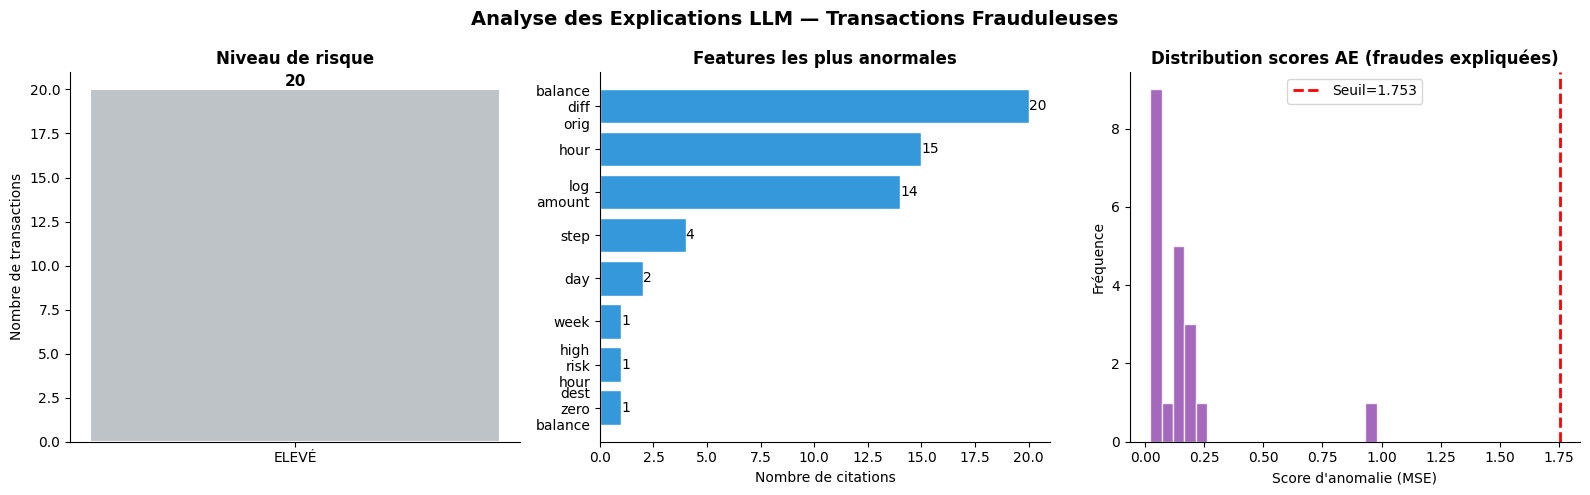

Figure sauvegardée : 35_ollama_analysis.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analyse des Explications LLM — Transactions Frauduleuses', fontsize=14, fontweight='bold')

COLORS = {'CRITIQUE': '#C0392B', 'ÉLEVÉ': '#E67E22', 'MODÉRÉ': '#F1C40F',
          'HAUTE': '#27AE60', 'MOYENNE': '#3498DB', 'FAIBLE': '#95A5A6'}

# ── Graphe 1 : Répartition des niveaux de risque ──────────────────────────────
ax = axes[0]
risk_labels = [k for k in risk_counts if k != '?']
risk_values = [risk_counts[k] for k in risk_labels]
colors_risk = [COLORS.get(k, '#BDC3C7') for k in risk_labels]
bars = ax.bar(risk_labels, risk_values, color=colors_risk, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='%d', fontsize=11, fontweight='bold')
ax.set_title('Niveau de risque', fontweight='bold')
ax.set_ylabel('Nombre de transactions')
ax.set_xlabel('')
ax.spines[['top','right']].set_visible(False)

# ── Graphe 2 : Top features citées ────────────────────────────────────────────
ax = axes[1]
top_feats = sorted(
    [(f, c) for f, c in feature_mentions.items() if c > 0],
    key=lambda x: -x[1]
)[:8]
feat_names   = [f.replace('_', '\n') for f, _ in top_feats]
feat_counts  = [c for _, c in top_feats]
bars2 = ax.barh(feat_names[::-1], feat_counts[::-1], color='#3498DB', edgecolor='white')
ax.bar_label(bars2, fmt='%d', fontsize=10)
ax.set_title('Features les plus anormales', fontweight='bold')
ax.set_xlabel('Nombre de citations')
ax.spines[['top','right']].set_visible(False)

# ── Graphe 3 : Distribution des scores AE pour les transactions expliquées ────
ax = axes[2]
explained_idx = [e['transaction_idx'] for e in explanations if 'transaction_idx' in e]
explained_scores = ae_scores_test[explained_idx] if explained_idx else flagged_scores
ax.hist(explained_scores, bins=20, color='#8E44AD', alpha=0.8, edgecolor='white')
ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Seuil={threshold:.3f}')
ax.set_title('Distribution scores AE (fraudes expliquées)', fontweight='bold')
ax.set_xlabel('Score d\'anomalie (MSE)')
ax.set_ylabel('Fréquence') 
ax.legend()
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '35_ollama_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : 35_ollama_analysis.png')

In [15]:
print("Nombre total explanations :", len(explanations))

from collections import Counter
print("Statuses :", Counter(e.get("status") for e in explanations))

Nombre total explanations : 20
Statuses : Counter({'ok': 20})


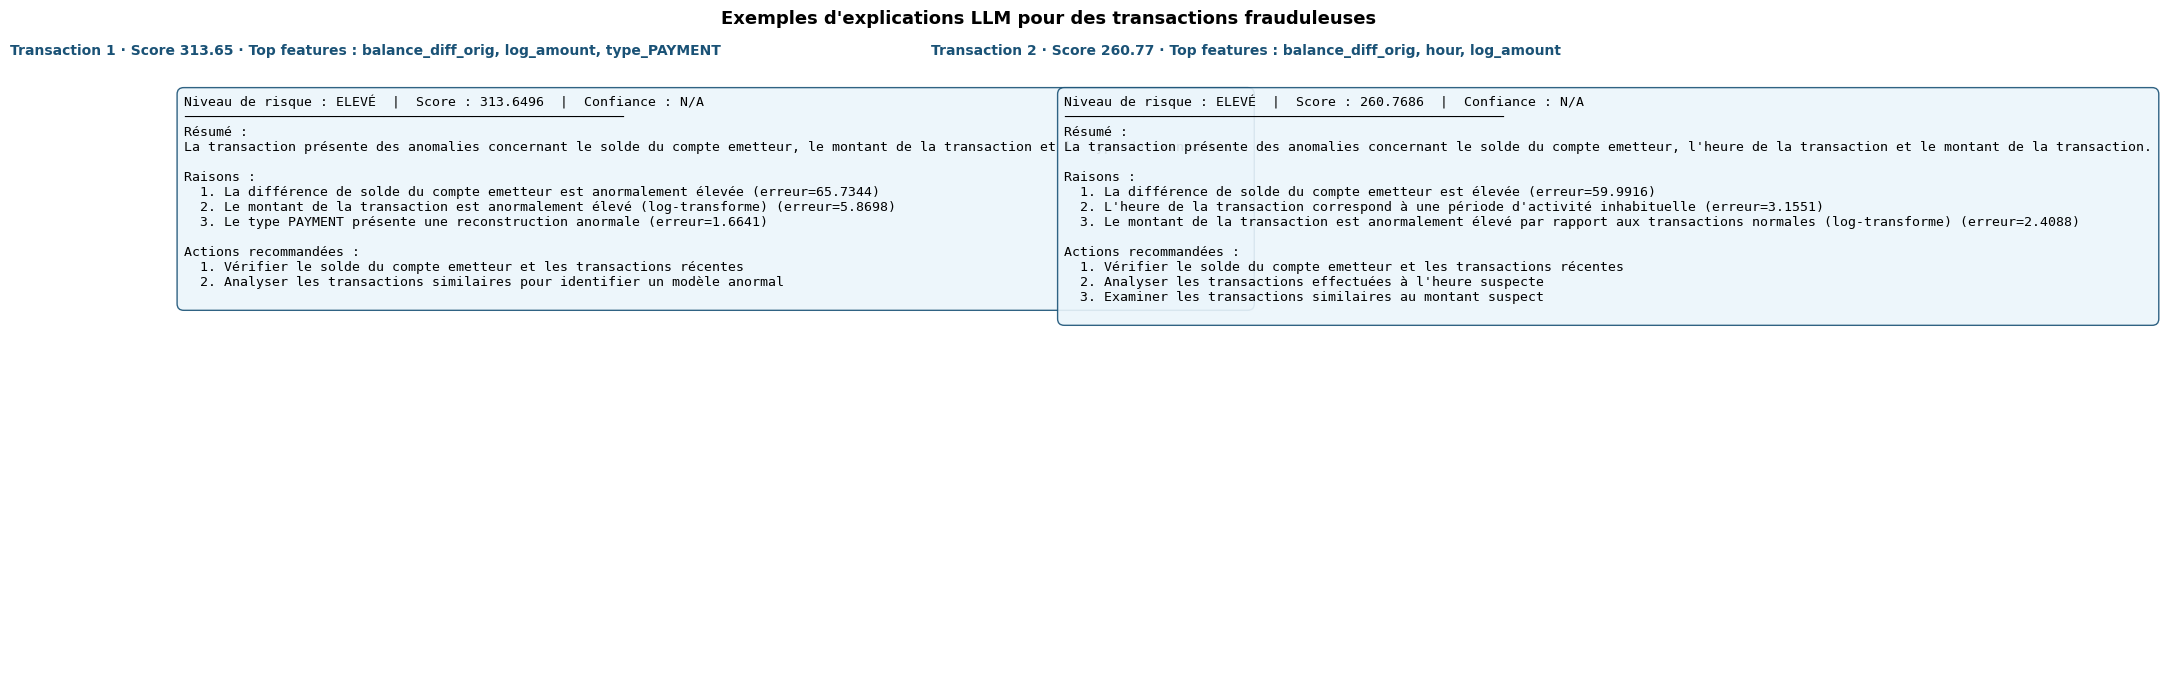

Figure sauvegardée : 36_explanation_examples.png


In [16]:
# ── Figure 36 : Exemples d'explications ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Exemples d\'explications LLM pour des transactions frauduleuses', fontsize=13, fontweight='bold')

# Prendre 2 exemples : meilleur TP (score le plus élevé) et pire TP (score le plus bas)
# Accepter toutes les explications (ok, fallback, timeout — toutes ont les données)
ok_expls = [e for e in explanations if e.get('raisons')]  # filtre : données présentes

for ax_idx, (ax, expl) in enumerate(zip(axes, ok_expls[:2])):
    ax.axis('off')
    risk   = expl.get('risk_level', 'N/A')
    score  = expl.get('ae_score', 0)   
    resume = expl.get('resume', 'N/A')
    raisons = expl.get('raisons', [])
    actions = expl.get('actions_recommandees', [])
    conf   = expl.get('confiance', 'N/A')

    color  = {'CRITIQUE': '#FADBD8', 'ÉLEVÉ': '#FDEBD0', 'MODÉRÉ': '#FEF9E7'}.get(risk, '#EBF5FB')
    t_color = {'CRITIQUE': '#922B21', 'ÉLEVÉ': '#784212', 'MODÉRÉ': '#7D6608'}.get(risk, '#1A5276')

    txt  = f'Niveau de risque : {risk}  |  Score : {score:.4f}  |  Confiance : {conf}\n'
    txt += '─' * 55 + '\n'
    txt += f'Résumé :\n{resume}\n\n'
    txt += 'Raisons :\n'
    for i, r in enumerate(raisons, 1):
        txt += f'  {i}. {r}\n'
    txt += '\nActions recommandées :\n'
    for i, a in enumerate(actions, 1):
        txt += f'  {i}. {a}\n'

    ax.text(0.05, 0.95, txt, transform=ax.transAxes,
            fontsize=9.5, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.9, edgecolor=t_color))
    ax.set_title(f'Transaction {ax_idx+1} · Score {expl.get("ae_score",0):.2f} · Top features : ' +
                 ', '.join(tf["feature"] for tf in expl.get("top_features",[])[:3]),
                 fontsize=10, color=t_color, fontweight='bold')

plt.tight_layout()
fig.savefig(FIGURES_DIR / '36_explanation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : 36_explanation_examples.png')

## 11 — Sauvegarde

In [17]:
# ── explanations.json ─────────────────────────────────────────────────────────
from collections import Counter

def resolve_output_path(path_like):
    path = Path(path_like)
    if not path.is_absolute():
        path = (project_root / path).resolve()
    path.parent.mkdir(parents=True, exist_ok=True)
    return path

output_path = resolve_output_path(EXPLANATIONS_PATH)

# Rehydrate missing state when this cell is run out of order.
if 'explanations' not in globals():
    if output_path.exists():
        with open(output_path, encoding='utf-8') as f:
            explanations = json.load(f)
        print(f'Info: explications rechargees depuis {output_path}')
    else:
        explanations = []

if 'flagged_mask' not in globals():
    flagged_mask = np.asarray(ae_scores_test) >= threshold

if 'flagged_idx' not in globals():
    flagged_idx = np.where(flagged_mask)[0]

if 'n_flagged' not in globals():
    n_flagged = int(flagged_mask.sum())

y_test_arr = np.asarray(y_test)
if 'n_tp' not in globals():
    n_tp = int(np.sum(flagged_mask & (y_test_arr == 1)))
if 'n_fp' not in globals():
    n_fp = int(np.sum(flagged_mask & (y_test_arr == 0)))
if 'n_fn' not in globals():
    n_fn = int(np.sum((~flagged_mask) & (y_test_arr == 1)))

status_counts    = dict(Counter(expl.get('status', '?') for expl in explanations))
risk_counts      = dict(Counter(expl.get('risk_level', '?') for expl in explanations))
confiance_counts = dict(Counter(expl.get('confiance', '?') for expl in explanations))
feature_mentions = {f: 0 for f in FEATURE_COLS}
for expl in explanations:
    for tf in expl.get('top_features', []):
        feat = tf.get('feature', '')
        if feat in feature_mentions:
            feature_mentions[feat] += 1

top_feats = sorted(
    [(f, c) for f, c in feature_mentions.items() if c > 0],
    key=lambda x: -x[1]
)[:8]

with open(output_path, 'w', encoding='utf-8') as f:
    json.dump(explanations, f, ensure_ascii=False, indent=2)
print(f'✅ explanations.json sauvegardé ({len(explanations)} explications)')
print(f'   {output_path}')

# ── llm_summary.json ──────────────────────────────────────────────────────────
summary = {
    'n_flagged_total'      : int(n_flagged),
    'n_explained'          : len(explanations),
    'n_tp'                 : int(n_tp),
    'n_fp'                 : int(n_fp),
    'ae_threshold'         : float(threshold),
    'ae_recall'            : float(AE_RECALL_TEST),
    'ae_f1'                : float(AE_F1_TEST),
    'rf_smote_recall'      : float(RF_RECALL),
    'rf_smote_f1'          : float(RF_F1),
    'risk_distribution'    : risk_counts,
    'confiance_distribution': confiance_counts,
    'status_distribution'  : status_counts,
    'top_features_cited'   : [{'feature': f, 'count': c} for f, c in top_feats],
    'llm_model'            : LLM_MODEL,
    'llm_provider'         : LLM_PROVIDER,
    'llm_available'        : helper.is_available(),
}

summary_path = resolve_output_path(LLM_SUMMARY_PATH)
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f'✅ llm_summary.json sauvegardé')
print(f'   {summary_path}')

✅ explanations.json sauvegardé (20 explications)
   C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\reports\explanations.json
✅ llm_summary.json sauvegardé
   C:\Users\lenovo\Desktop\anomaly_detection_project\outputs\reports\llm_summary.json


## 12 — Synthèse finale

In [18]:
print('=' * 60)
print('  SYNTHÈSE — NB06 LLM')
print('=' * 60)
print()
print(f'  AutoEncoder (NB04) :')
print(f'    Recall        : {AE_RECALL_TEST:.4f}')
print(f'    F1-Score      : {AE_F1_TEST:.4f}')
print(f'    Seuil         : {threshold:.6f}')
print() 
print(f'  Transactions flaggées  : {n_flagged}')
print(f'  Explications générées  : {len(explanations)}')
llm_model_name = LLM_MODEL or (helper.config.get('model') if hasattr(helper, 'config') else None) or 'rule_based'
print(f'  Mode LLM               : {LLM_PROVIDER.upper()} / {llm_model_name if helper.is_available() else "Fallback rule-based"}')
print()
print(f'  Répartition risque :')
for k, v in sorted(risk_counts.items(), key=lambda x: -x[1]):
    if k != '?':
        print(f'    {k:<12s} : {v}')
print()
print(f'  Feature #1 la plus citée : {top_feats[0][0] if top_feats else "N/A"}')
print()
print(f'  Artefacts sauvegardés :')
print(f'    outputs/reports/explanations.json')
print(f'    outputs/reports/llm_summary.json')
print(f'    outputs/figures/35_llm_analysis.png')
print(f'    outputs/figures/36_explanation_examples.png')
print('=' * 60)
print()
print('✅ NB06 terminé. Pipeline complet :')
print('   NB01 EDA → NB02 Préparation → NB03 Baselines ML')
print('   → NB04 AutoEncoder → NB05 SHAP+LIME → NB06 Explications LLM')

  SYNTHÈSE — NB06 LLM

  AutoEncoder (NB04) :
    Recall        : 0.3590
    F1-Score      : 0.4516
    Seuil         : 1.753022

  Transactions flaggées  : 23
  Explications générées  : 20
  Mode LLM               : GROQ / llama-3.1-8b-instant

  Répartition risque :
    ELEVÉ        : 20

  Feature #1 la plus citée : balance_diff_orig

  Artefacts sauvegardés :
    outputs/reports/explanations.json
    outputs/reports/llm_summary.json
    outputs/figures/35_llm_analysis.png
    outputs/figures/36_explanation_examples.png

✅ NB06 terminé. Pipeline complet :
   NB01 EDA → NB02 Préparation → NB03 Baselines ML
   → NB04 AutoEncoder → NB05 SHAP+LIME → NB06 Explications LLM
